In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
#switch out for your version of uproot
from importlib_metadata import version

import uproot4 as uproot
import pandas as pd
import numpy as np
import math
from tqdm import tqdm

import xgboost as xgb
#from sklearn.preprocessing import OrdinalEncoder
#from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
#from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import RandomizedSearchCV
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import f_regression


import scipy.stats as stats
from scipy.stats import norm

from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)

import random

print("uproot4 version:", version("uproot4"))
print(pd.__version__)

uproot4 version: 4.0.0
2.2.3


In [3]:
#function to calculate the angle wrt the beam
def get_angle(momentum_0,momentum_1,momentum_2):
    momentum_perp = np.sqrt(momentum_0 * momentum_0 + momentum_1 * momentum_1)
    # defined in https://root.cern/doc/master/TVector3_8cxx_source.html
    theta = np.arctan2(momentum_perp, momentum_2)
    phi = np.arctan2(momentum_0, momentum_1)
    return theta, phi

def get_bin_centers(x):
    centers = []
    for i in range(len(x)-1): centers.append( x[i] + (x[i+1]-x[i])/2 )
    return centers

In [4]:
nu_overlay_run4_super_df = pd.read_pickle('numi_run4b_mc.pkl')

In [5]:

# GeV masses
_MASS = {13: 0.105658, 2212: 0.938272, 211: 0.13957, 11: 0.000511, 111: 0.134977}

def _extract_E_component(startM):
    arr = np.asarray(startM, dtype=object)
    if arr.ndim == 2 and arr.shape[1] >= 4:
        return arr[:, 3].astype(float)
    if arr.ndim == 1 and len(arr) % 4 == 0 and not isinstance(arr[0], (list, np.ndarray)):
        return np.asarray(arr, dtype=float).reshape(-1, 4)[:, 3]
    if arr.ndim == 1 and isinstance(arr[0], (list, np.ndarray)) and len(arr[0]) >= 4:
        return np.array([row[3] for row in arr], dtype=float)
    return np.asarray(arr, dtype=float)

def _infer_ke_GeV(pdg, Ecomp):
    """Return (KE_GeV, mode_str). If numbers look GeV-scale -> treat as TOTAL E in GeV and do E-m.
       Else treat as KE in MeV and convert to GeV.
    """
    E = np.asarray(Ecomp, dtype=float)
    finite = np.isfinite(E)
    med = np.median(np.abs(E[finite])) if np.any(finite) else 0.0

    if 0.005 <= med <= 10.0:   # looks like GeV scale -> total energy
        masses = np.vectorize(lambda p: _MASS.get(int(p), 0.0))(pdg)
        return np.clip(E - masses, 0.0, None), "E_total_GeV"
    else:                       # looks like MeV scale -> kinetic energy in MeV
        return np.clip(E, 0.0, None) / 1000.0, "KE_MeV"

def run_pf_cutflow(df, base_mask):
    """Count first-failure stage for PF cuts on base-pass events.
       Adds df.loc[base_mask, 'pf_first_fail'] with first failing stage label (or 'PASS').
       Returns a dict of counts and prints a compact report.
    """
    # Ensure PF columns are object (prevents pandas EA reshape issues)
    for c in ["reco_pdg", "reco_mother", "reco_startMomentum"]:
        df[c] = df[c].astype("object")

    stages = [
        "malformed",            # arrays missing / length mismatch / empty
        "mu_prim!=1",           # exactly one primary muon > 10 MeV
        "mu_sec>0",             # no secondary muons > 10 MeV
        "p_prim!=1",            # exactly one primary proton > 50 MeV
        "p_sec>0",              # no secondary protons > 50 MeV
        "pi_any>0",             # no charged pions > 10 MeV
        "e_any>0",              # no showers/electrons > 70 MeV
        "pi0_any>0",            # no neutral pions (any KE)
        "PASS",
    ]
    counts = {k: 0 for k in stages}
    energy_mode_counts = {"E_total_GeV": 0, "KE_MeV": 0}

    # record first fail per event (for later debugging)
    pf_first_fail = pd.Series(index=df.index, dtype="object")

    idxs = df.index[base_mask]
    for i, (pdg, mom, sm) in zip(idxs, zip(df.loc[idxs, "reco_pdg"],
                                           df.loc[idxs, "reco_mother"],
                                           df.loc[idxs, "reco_startMomentum"])):
        # basic checks
        try:
            pdg = np.asarray(pdg)
            mom = np.asarray(mom)
            E4  = _extract_E_component(sm)
        except Exception:
            counts["malformed"] += 1
            pf_first_fail.loc[i] = "malformed"
            continue

        if pdg.size == 0 or mom.size != pdg.size or E4.size != pdg.size:
            counts["malformed"] += 1
            pf_first_fail.loc[i] = "malformed"
            continue

        # primary definition: accept mother <= 0 (covers 0 and -1)
        primary   = (mom <= 0)
        secondary = ~primary

        KE, mode = _infer_ke_GeV(pdg, E4)
        if mode in energy_mode_counts:
            energy_mode_counts[mode] += 1

        # particle tags
        is_mu  = (pdg == 13)
        is_p   = (pdg == 2212)
        is_pi  = (pdg == 211)
        is_e   = (pdg == 11)
        is_pi0 = (pdg == 111)

        # thresholds (GeV)
        mu_prim = np.sum(primary   & is_mu & (KE > 0.010))  # >10 MeV
        mu_sec  = np.sum(secondary & is_mu & (KE > 0.010))
        p_prim  = np.sum(primary   & is_p  & (KE > 0.050))  # >50 MeV
        p_sec   = np.sum(secondary & is_p  & (KE > 0.050))
        pi_any  = np.sum(is_pi & (KE > 0.010))
        e_any   = np.sum(is_e  & (KE > 0.070))
        pi0_any = np.sum(is_pi0)

        # stagewise first-failure
        if mu_prim != 1:
            counts["mu_prim!=1"] += 1
            pf_first_fail.loc[i] = "mu_prim!=1"
            continue
        if mu_sec > 0:
            counts["mu_sec>0"] += 1
            pf_first_fail.loc[i] = "mu_sec>0"
            continue
        if p_prim != 1:
            counts["p_prim!=1"] += 1
            pf_first_fail.loc[i] = "p_prim!=1"
            continue
        if p_sec > 0:
            counts["p_sec>0"] += 1
            pf_first_fail.loc[i] = "p_sec>0"
            continue
        if pi_any > 0:
            counts["pi_any>0"] += 1
            pf_first_fail.loc[i] = "pi_any>0"
            continue
        if e_any > 0:
            counts["e_any>0"] += 1
            pf_first_fail.loc[i] = "e_any>0"
            continue
        if pi0_any > 0:
            counts["pi0_any>0"] += 1
            pf_first_fail.loc[i] = "pi0_any>0"
            continue

        counts["PASS"] += 1
        pf_first_fail.loc[i] = "PASS"

    # attach column (only for base-pass rows)
    df.loc[idxs, "pf_first_fail"] = pf_first_fail.loc[idxs].values

    # print compact report
    total = len(idxs)
    print(f"Base-pass events examined: {total}")
    for k in ["malformed","mu_prim!=1","mu_sec>0","p_prim!=1","p_sec>0","pi_any>0","e_any>0","pi0_any>0","PASS"]:
        print(f"{k:>12}: {counts[k]:5d}  ({(counts[k]/total*100 if total else 0):5.1f}%)")
    print("Energy interpretation counts:", energy_mode_counts)

    return {"counts": counts, "energy_modes": energy_mode_counts}


# Your base mask:
base_mask = (
    (nu_overlay_run4_super_df["numu_score"] > 0.9) &
    (nu_overlay_run4_super_df["nue_score"]  < 7.0) &
    (nu_overlay_run4_super_df["match_isFC"] == 1)
)
if "ncpi0_score" in nu_overlay_run4_super_df.columns:
    base_mask &= (nu_overlay_run4_super_df["ncpi0_score"] < 1.816)

result = run_pf_cutflow(nu_overlay_run4_super_df, base_mask)

# Now you can quickly see which stage nuked an event:
nu_overlay_run4_super_df["pf_first_fail"].value_counts(dropna=False)

# And, if you want the final selection flag in the same pass:
nu_overlay_run4_super_df["sel_numuCC_1mu1p"] = (base_mask) & (nu_overlay_run4_super_df["pf_first_fail"] == "PASS")
print("Final selected:", nu_overlay_run4_super_df["sel_numuCC_1mu1p"].sum())

Base-pass events examined: 27996
   malformed:     0  (  0.0%)
  mu_prim!=1:  7734  ( 27.6%)
    mu_sec>0:  3588  ( 12.8%)
   p_prim!=1: 10264  ( 36.7%)
     p_sec>0:   739  (  2.6%)
    pi_any>0:   802  (  2.9%)
     e_any>0:  1441  (  5.1%)
   pi0_any>0:     0  (  0.0%)
        PASS:  3428  ( 12.2%)
Energy interpretation counts: {'E_total_GeV': 24532, 'KE_MeV': 3464}
Final selected: 3428


In [6]:
#numucc signal
sig_query = "truth_isCC==1 and truth_nuPdg==14"
#numucc selection
sel_query = "numu_cc_flag>=0 and numu_score > 0.9"
# "NC" selection. mostly just the base for the cut based NCpi0 selection
NC_query = "cosmict_flag==0 and numu_score < 0"
#CC pi0 cut based selection
CCpi0_query = sel_query + ' and ((kine_pio_vtx_dis < 9 ) and kine_pio_energy_1* @em_charge_scale > 40 and kine_pio_energy_2* @em_charge_scale > 25 and kine_pio_dis_1 < 110 and kine_pio_dis_2 < 120 and kine_pio_angle > 0 and kine_pio_angle < 174  and pio_mass > 22 and pio_mass < 300)'
#NC pi0 cut based selection
NCpi0_query = NC_query + ' and ((kine_pio_flag==1 and kine_pio_vtx_dis < 9 or kine_pio_flag==2) and kine_pio_energy_1* em_charge_scale > 40 and kine_pio_energy_2* em_charge_scale > 25 and kine_pio_dis_1 < 110 and kine_pio_dis_2 < 120 and kine_pio_angle > 0 and kine_pio_angle < 174  and pio_mass > 22 and pio_mass < 300)'
#CC+NC pi0 cut based selection
pi0_query = '((kine_pio_flag==1 and kine_pio_vtx_dis < 9 or kine_pio_flag==2) and kine_pio_energy_1* em_charge_scale > 40 and kine_pio_energy_2* em_charge_scale > 25 and kine_pio_dis_1 < 110 and kine_pio_dis_2 < 120 and kine_pio_angle > 0 and kine_pio_angle < 174  and pio_mass > 22 and pio_mass < 300)'
#NC pi0 BDT based selection
NCpi0_bdt_query = 'nc_pio_score > 1.816 and kine_pio_energy_1 > 0 and kine_pio_energy_2 > 0'

In [7]:
print(nu_overlay_run4_super_df.columns.to_list())

['index', 'mip_energy', 'mip_angle_beam', 'spt_angle_vertical', 'nue_score', 'numu_score', 'numu_cc_flag', 'numu_1_score', 'numu_cc_3_track_length', 'numu_cc_3_max_length_all', 'cosmict_2_dQ_dx_front', 'cosmict_2_dQ_dx_end', 'cosmict_2_angle_beam', 'cosmict_2_phi', 'numu_cc_3_max_length', 'numu_cc_3_max_muon_length', 'numu_cc_flag_1', 'numu_cc_flag_2', 'numu_cc_flag_3', 'cosmict_flag', 'numu_cc_1_length', 'numu_cc_1_direct_length', 'numu_cc_2_length', 'numu_cc_2_total_length', 'run', 'subrun', 'event', 'flash_found', 'flash_time', 'flash_found_asInt', 'match_found_asInt', 'flash_measPe', 'flash_predPe', 'match_found', 'match_type', 'match_isFC', 'match_isTgm', 'match_notFC_FV', 'match_notFC_SP', 'match_notFC_DC', 'match_chargeU', 'match_chargeV', 'match_chargeY', 'match_energyY', 'light_mismatch', 'match_charge', 'match_energy', 'stm_eventtype', 'stm_lowenergy', 'stm_LM', 'stm_TGM', 'stm_STM', 'stm_FullDead', 'stm_clusterlength', 'evtTimeNS_cor', 'reco_muonMomentum', 'reco_protonMoment

In [8]:
# quick sample check
s = nu_overlay_run4_super_df["reco_pdg"].dropna().sample(1000, random_state=0)

# flatten per-event arrays/lists
vals = s.explode()

print("Unique PDGs in sample:", sorted(vals.unique()))


Unique PDGs in sample: [11, 13, 22, 111, 211, 2112, 2212]


In [9]:
print(n

SyntaxError: incomplete input (2169868425.py, line 1)

# Classification BDT (on or off target)

In [10]:
train_vars_slim = [
    'mip_energy', 'spt_angle_vertical',
    'nue_score', 'numu_score', 'numu_1_score',
    'numu_cc_3_track_length',
    'numu_cc_3_max_length', 'numu_cc_3_max_muon_length',

    'cosmict_2_dQ_dx_end',
    'cosmict_2_phi',
    'cosmict_flag',

    'stm_eventtype', 'stm_lowenergy',
    'stm_LM', 'stm_TGM', 'stm_STM',
    'stm_FullDead', 'stm_clusterlength',

    'evtTimeNS_cor', 'merge_time', 'times_adjusted',

    'reco_muonMomentum', 'reco_protonMomentum',
    'reco_Eproton', 'Ehadron',

    'reco_nuvtxX', 'reco_nuvtxY', 'reco_nuvtxZ',
    'reco_muonvtxX', 'reco_muonvtxY', 'reco_muonvtxZ',

    'reco_showerMomentum',
    'reco_Ntrack',

    'reco_muon_phi',
    'reco_muon_cosphi',

    'reco_nu_numi_theta',

    'con_track_1_KE',
    'allcon_track_1_KE',

    'prim_e_1_KE', 'prim_e_2_KE',
    'allcon_e_1_KE', 'allcon_e_2_KE',

    'g_2_KE',
    'prim_g_1_KE', 'prim_g_2_KE',

    'pf_con_muon_1_E', 'pf_con_muon_2_E',

    'pf_p_1_E',
    'pf_prim_p_1_E',

    'reco_pi0_mom',
    'reco_pi0_mom_2',

    'kine_reco_Enu',
    'kine_pio_flag',
    'kine_pio_vtx_dis',
    'kine_pio_energy_1', 'kine_pio_theta_1',
    'kine_pio_phi_1', 'kine_pio_dis_1'
]

In [ ]:
# Create flags for each particle type
nu_overlay_run4_super_df["has_electron"] = nu_overlay_run4_super_df["reco_pdg"].apply(
    lambda x: 11 in x if isinstance(x, (list, np.ndarray)) else False
)
nu_overlay_run4_super_df["has_muon"] = nu_overlay_run4_super_df["reco_pdg"].apply(
    lambda x: 13 in x if isinstance(x, (list, np.ndarray)) else False
)
nu_overlay_run4_super_df["has_pion_neutral"] = nu_overlay_run4_super_df["reco_pdg"].apply(
    lambda x: 111 in x if isinstance(x, (list, np.ndarray)) else False
)
nu_overlay_run4_super_df["has_pion_charged"] = nu_overlay_run4_super_df["reco_pdg"].apply(
    lambda x: 211 in x if isinstance(x, (list, np.ndarray)) else False
)
nu_overlay_run4_super_df["has_neutron"] = nu_overlay_run4_super_df["reco_pdg"].apply(
    lambda x: 2112 in x if isinstance(x, (list, np.ndarray)) else False
)
nu_overlay_run4_super_df["has_proton"] = nu_overlay_run4_super_df["reco_pdg"].apply(
    lambda x: 2212 in x if isinstance(x, (list, np.ndarray)) else False
)


In [13]:
# What is the subset of events you want to be training on, should include both "signal and background"
#clean selection: sel_numuCC_1mu1p==True
true_query = "index >= 0"
reco_query = "index >= 0"
# Creating a dataframe with 50%
# values of original dataframe
fraction = 0.5
temp_df = nu_overlay_run4_super_df.query(true_query).query(reco_query)
temp_df = temp_df.reset_index()
train_df = temp_df.sample(frac = fraction)
test_df = temp_df.drop(train_df.index)

In [ ]:
# What is the name of the BDT score you will be createing
bdt_score_name = "score_mcflux_vz_gt500"
# Define what variables your BDT is going to be using for prediction
train_vars_more = train_vars_slim
# How many of these we will "downselect" to in the final BDT, high number means just use all of them
num_vars = 30

train_df['mcflux_vz_gt500'] = (train_df['mcflux_vz'] > 500).astype(int)
test_df['mcflux_vz_gt500'] = (test_df['mcflux_vz'] > 500).astype(int)

# Define what variable your BDT is going to trying to predict
target_var = 'mcflux_vz_gt500'
# Go to an even small subset of the data just for the training if you desire, as is, this will just take all events
further_subset_query = reco_query

# Number of rounds to train for
n = 200
# Define the hyperparameter distributions, these will be optimized in this regime in the BDT training
param_dist = {
    'max_depth': stats.randint(3, 10),
    'eta': stats.uniform(0.01, 0.3),  
    'gamma':stats.uniform(0, 5),
    'lambda':stats.uniform(0, 3),
    'alpha':stats.uniform(0, 3),
    'min_child_weight':stats.uniform(1, 9),
     'colsample_bytree': stats.uniform(0.6, 0.4),
     'colsample_bylevel': stats.uniform(0.6, 0.4)
}


train_df["mcflux_vz_gt0"] = (train_df["mcflux_vz"] + 380).astype(int)
test_df["mcflux_vz_gt0"] = (test_df["mcflux_vz"] + 380).astype(int)

# Extract feature and target arrays
X_test = test_df.query(further_subset_query)[train_vars_more].copy()
X_train = train_df.query(further_subset_query)[train_vars_more].copy()
y_test = test_df.query(further_subset_query)[[target_var]].copy()
y_train = train_df.query(further_subset_query)[[target_var]].copy()

# Convert awkward arrays to scalar values BEFORE fillna
for col in X_train.columns:
    try:
        if hasattr(X_train[col].iloc[0], '__len__') and not isinstance(X_train[col].iloc[0], str):
            X_train[col] = X_train[col].apply(lambda x: float(x[0]) if isinstance(x, (list, tuple, np.ndarray)) and len(x) > 0 else 0.0)
            X_test[col] = X_test[col].apply(lambda x: float(x[0]) if isinstance(x, (list, tuple, np.ndarray)) and len(x) > 0 else 0.0)
    except (TypeError, IndexError, AttributeError):
        X_train[col] = 0.0
        X_test[col] = 0.0

# NOW fillna to catch any remaining NaNs
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# Convert to numeric
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# Replace infinities
X_train = X_train.replace([np.inf, -np.inf], 0.0)
X_test = X_test.replace([np.inf, -np.inf], 0.0)

# Diagnostic
print("X_train NaN count:", X_train.isna().sum().sum())
print("X_test NaN count:", X_test.isna().sum().sum())


# Downselect to the num_vars "most predictive" variables
presel_model_kp1540_proton_more = SelectKBest(f_classif, k=num_vars).fit(X_train, y_train)
new_names_kp1540_proton_more = list(presel_model_kp1540_proton_more.get_feature_names_out())
X_train = presel_model_kp1540_proton_more.transform(X_train)
X_test = presel_model_kp1540_proton_more.transform(X_test)


# Create the XGBoost model object
xgb_model_kp1540_proton_more = xgb.XGBClassifier()

# Create and execute the RandomizedSearchCV object which does the hyperparameter tuning
random_search_kp1540_proton_more = RandomizedSearchCV(xgb_model_kp1540_proton_more, param_distributions=param_dist, n_iter=100, cv=5, scoring='roc_auc')
random_search_kp1540_proton_more.fit(X_train, y_train)
print("Best set of hyperparameters: ", random_search_kp1540_proton_more.best_params_)
print("Best score: ", random_search_kp1540_proton_more.best_score_)
new_params_kp1540_proton_more = random_search_kp1540_proton_more.best_params_

# Test your BDT it is doing classification and to output a score from 0 to 1
new_params_kp1540_proton_more["objective"] =  "binary:logistic"

# Do the training of the BDT
dtrain_reg = xgb.DMatrix(X_train, y_train, enable_categorical=True,feature_names=new_names_kp1540_proton_more)
dtest_reg = xgb.DMatrix(X_test, y_test, enable_categorical=True,feature_names=new_names_kp1540_proton_more)
evals = [(dtest_reg, "validation"), (dtrain_reg, "train")]
evals_result_kp1540_proton_more = {}
model_kp1540_proton_more = xgb.train(
   params=random_search_kp1540_proton_more.best_params_,
   dtrain=dtrain_reg,
   num_boost_round=n,
   evals=evals,
   verbose_eval=200,
    evals_result=evals_result_kp1540_proton_more
)

# Add these scores back to the data frame
d_pred_df = test_df[new_names_kp1540_proton_more].copy()

# Convert awkward arrays in prediction data (same as training)
for col in d_pred_df.columns:
    try:
        if hasattr(d_pred_df[col].iloc[0], '__len__') and not isinstance(d_pred_df[col].iloc[0], str):
            d_pred_df[col] = d_pred_df[col].apply(lambda x: float(x[0]) if isinstance(x, (list, tuple, np.ndarray)) and len(x) > 0 else 0.0)
    except (TypeError, IndexError, AttributeError):
        d_pred_df[col] = 0.0

d_pred_df = d_pred_df.fillna(0).astype(float).replace([np.inf, -np.inf], 0.0)

d_reg = xgb.DMatrix(d_pred_df, enable_categorical=True)
d_pred = model_kp1540_proton_more.predict(d_reg)
test_df[bdt_score_name] = d_pred

# Same for train_df
d_pred_df = train_df[new_names_kp1540_proton_more].copy()

for col in d_pred_df.columns:
    try:
        if hasattr(d_pred_df[col].iloc[0], '__len__') and not isinstance(d_pred_df[col].iloc[0], str):
            d_pred_df[col] = d_pred_df[col].apply(lambda x: float(x[0]) if isinstance(x, (list, tuple, np.ndarray)) and len(x) > 0 else 0.0)
    except (TypeError, IndexError, AttributeError):
        d_pred_df[col] = 0.0

d_pred_df = d_pred_df.fillna(0).astype(float).replace([np.inf, -np.inf], 0.0)

d_reg = xgb.DMatrix(d_pred_df, enable_categorical=True)
d_pred = model_kp1540_proton_more.predict(d_reg)
train_df[bdt_score_name] = d_pred


X_train NaN count: 0
X_test NaN count: 0


c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [13 14 15 16] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Best set of hyperparameters:  {'alpha': np.float64(2.6312106993473017), 'colsample_bylevel': np.float64(0.8944193005383221), 'colsample_bytree': np.float64(0.9440847022859524), 'eta': np.float64(0.05383806597586932), 'gamma': np.float64(2.057528974682285), 'lambda': np.float64(1.8065950243382494), 'max_depth': 6, 'min_child_weight': np.float64(2.538047940966829)}
Best score:  0.6841487649495297
[0]	validation-logloss:0.66368	train-logloss:0.66374
[199]	validation-logloss:0.60766	train-logloss:0.59274


electron (bad)
muon (2nd peak)
pion_neutral (low 2nd peak)
pion_charged (good dropoff)
neutron (2nd peak)
proton (good dropoff)

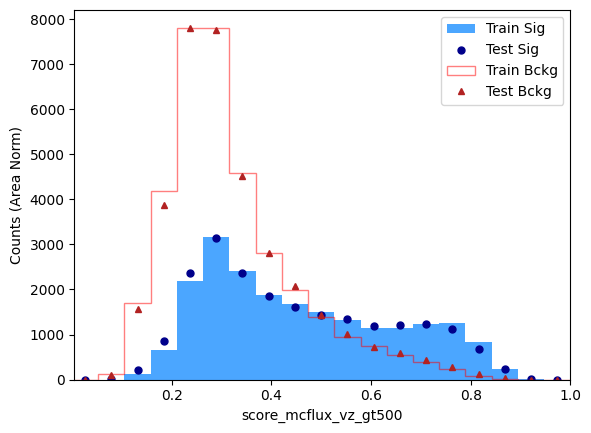

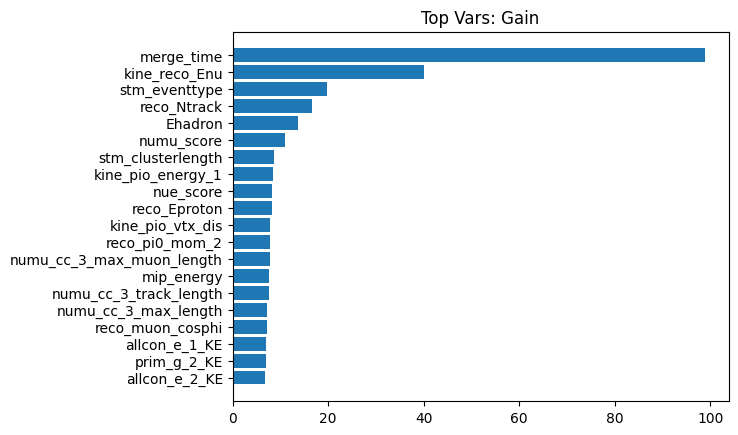

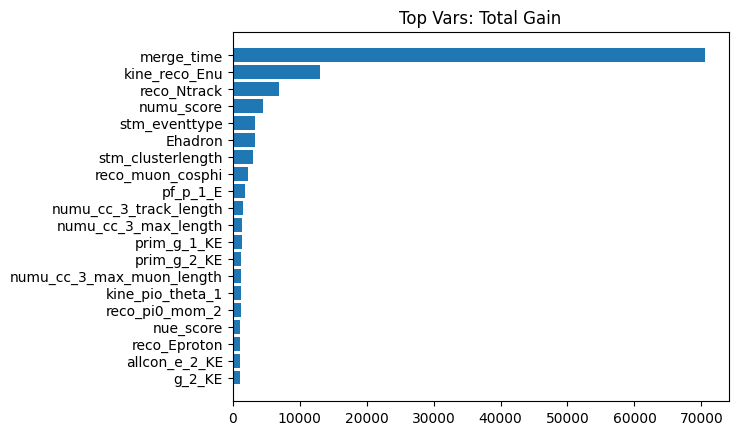

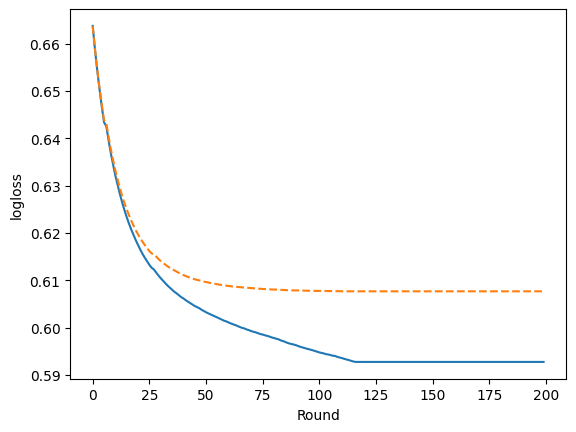

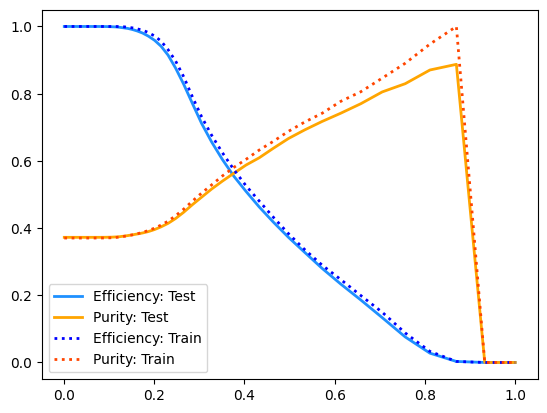

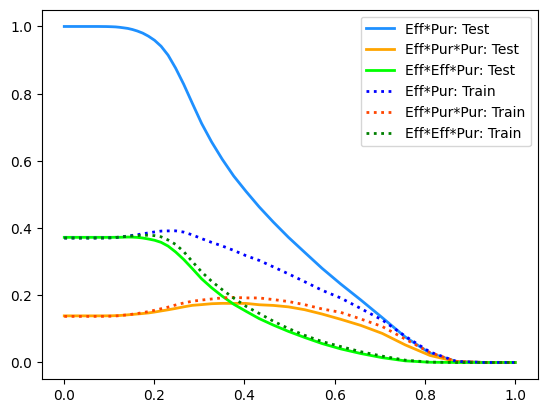

In [ ]:

plotit = True
plot_importance = True
max_items = 20
plot_loss = True
plot_eff = True
plot_subsection = "numu_score > 0.9 or sel_numuCC_1mu1p==True or nue_score > 7" or CCpi0_query or NCpi0_query

# Makes a plot of the score for signal and background
# Hopefuly you see good signal nad background separation here
# Also good to see similar performansce on test versus train
if plotit:    
    bins = np.linspace(1e-7, 1, num=20)      
    y_sig_test,x = np.histogram(test_df.query(plot_subsection).query(target_var+"==1")[bdt_score_name].to_numpy(),bins=bins,density=False)
    y_bck_test,x = np.histogram(test_df.query(plot_subsection).query(target_var+"==0")[bdt_score_name].to_numpy(),bins=bins,density=False)    
    plt.figure()
    plt.hist(train_df.query(plot_subsection).query(target_var+"==1")[bdt_score_name].to_numpy(),bins=bins,density=False,alpha=0.8,color="dodgerblue",label="Train Sig")
    plt.plot(get_bin_centers(x),y_sig_test,color="darkblue",marker="o",ms=5,lw=0,label="Test Sig")
    plt.hist(train_df.query(plot_subsection).query(target_var+"==0")[bdt_score_name].to_numpy(),bins=bins,density=False,alpha=0.5,color="red",label="Train Bckg",histtype="step")
    plt.plot(get_bin_centers(x),y_bck_test,marker="^",ms=5,lw=0,color="firebrick",label="Test Bckg")
    plt.legend()
    plt.xlim(0.005,1)
    plt.xlabel(bdt_score_name)
    plt.ylabel("Counts (Area Norm)")
    plt.show()
    


# Scores telling you which variables are being used by the BDT
if plot_importance:
    # Gain tells you the "local importance", when used to make a decision, how good is the variable?
    importance = model_kp1540_proton_more.get_score(importance_type='gain')
    full_lists = sorted(importance.items(), key=lambda x: x[1]) 
    if(len(full_lists)>max_items): lists = full_lists[len(full_lists)-max_items:]
    else: lists = full_lists
    x, y = zip(*lists) # unpack a list of pairs into two tuples
    plt.title("Top Vars: Gain")
    plt.barh(x,y)
    plt.show()
    
    # Total Gain tells you the "global importance", aggregated over all decisions, how good is the variable?
    importance = model_kp1540_proton_more.get_score(importance_type='total_gain')
    full_lists = sorted(importance.items(), key=lambda x: x[1]) 
    if(len(full_lists)>max_items): lists = full_lists[len(full_lists)-max_items:]
    else: lists = full_lists    
    x, y = zip(*lists) # unpack a list of pairs into two tuples
    plt.title("Top Vars: Total Gain")
    plt.barh(x,y)
    plt.show()

#Show test and training logloss 
if plot_loss:
    x = np.linspace(1,n,n)
    plt.figure()
    plt.plot(evals_result_kp1540_proton_more['train']['logloss'],label='train')
    plt.plot(evals_result_kp1540_proton_more['validation']['logloss'],label='test',ls='--')
    plt.ylabel("logloss")
    plt.xlabel("Round")
    plt.show()

# Plots purity and selection efficiency for the sample you are testing on.
if plot_eff:
    
    preds = test_df.query(plot_subsection)[bdt_score_name].to_numpy()
    
    cut_values = np.geomspace(1e-3, 1, num=100)
    eff_vec=[]
    pur_vec=[]
    effpur_vec=[]
    effpurpur_vec=[]
    effeffpur_vec=[]

    is_t0p = test_df.query(plot_subsection)[target_var].to_numpy()
    weights = np.ones_like(test_df.query(plot_subsection)[target_var].to_numpy())
    
    for j in range(len(cut_values)):
        cut = cut_values[j]
        n_sig=0
        n_sel=0
        n_sig_sel=0
        n_bck_selg_sel=0
        for i in range(len(is_t0p)):
            select=0
            if preds[i]>cut: 
                select=1
                n_sel+=weights[i]
            if is_t0p[i]==1: 
                n_sig+=weights[i]
                if select==1:n_sig_sel+=weights[i]
        eff_vec.append(n_sig_sel/n_sig)
        if n_sel==0: 
            pur_vec.append(0)
            effpur_vec.append(0)
            effpurpur_vec.append(0)
            effeffpur_vec.append(0)
        else: 
            pur_vec.append(n_sig_sel/n_sel)
            effpur_vec.append( (n_sig_sel/n_sig) * (n_sig_sel/n_sel) )
            effpurpur_vec.append( (n_sig_sel/n_sig) * (n_sig_sel/n_sel) * (n_sig_sel/n_sel) )
            effeffpur_vec.append( (n_sig_sel/n_sig) * (n_sig_sel/n_sig) * (n_sig_sel/n_sel) )



    preds = train_df.query(plot_subsection)[bdt_score_name].to_numpy()
    train_eff_vec=[]
    train_pur_vec=[]
    train_effpur_vec=[]
    train_effpurpur_vec=[]
    train_effeffpur_vec=[]
    
    is_t0p = train_df.query(plot_subsection)[target_var].to_numpy()
    weights = np.ones_like(train_df.query(plot_subsection)[target_var].to_numpy())

    for j in range(len(cut_values)):
        cut = cut_values[j]
        train_n_sig=0
        train_n_sel=0
        train_n_sig_sel=0
        train_n_bck_selg_sel=0
        for i in range(len(is_t0p)):
            select=0
            if preds[i]>cut: 
                select=1
                train_n_sel+=weights[i]
            if is_t0p[i]==1: 
                train_n_sig+=weights[i]
                if select==1:train_n_sig_sel+=weights[i]
        train_eff_vec.append(train_n_sig_sel/train_n_sig)
        if train_n_sel==0: 
            train_pur_vec.append(0)
            train_effpur_vec.append(0)
            train_effpurpur_vec.append(0)
            train_effeffpur_vec.append(0)
        else: 
            train_pur_vec.append(train_n_sig_sel/train_n_sel)
            train_effpur_vec.append( (train_n_sig_sel/train_n_sig) * (train_n_sig_sel/train_n_sel) )
            train_effpurpur_vec.append( (train_n_sig_sel/train_n_sig) * (train_n_sig_sel/train_n_sel) * (train_n_sig_sel/train_n_sel) )
            train_effeffpur_vec.append( (train_n_sig_sel/train_n_sig) * (train_n_sig_sel/train_n_sig) * (train_n_sig_sel/train_n_sel) )
            
    
    
    plt.figure() 
    plt.plot(cut_values,eff_vec,label="Efficiency: Test",color='dodgerblue',lw=2)
    plt.plot(cut_values,pur_vec,label="Purity: Test",color='orange',lw=2)
    plt.plot(cut_values,train_eff_vec,label="Efficiency: Train",color='blue',ls=":",lw=2)
    plt.plot(cut_values,train_pur_vec,label="Purity: Train",color='orangered',ls=":",lw=2)
    plt.legend()
    plt.show()
    
    plt.figure() 
    plt.plot(cut_values,eff_vec,label="Eff*Pur: Test",color='dodgerblue',lw=2)
    plt.plot(cut_values,effpurpur_vec,label="Eff*Pur*Pur: Test",color='orange',lw=2)
    plt.plot(cut_values,effeffpur_vec,label="Eff*Eff*Pur: Test",color='lime',lw=2)
    plt.plot(cut_values,train_effpur_vec,label="Eff*Pur: Train",color='blue',ls=":",lw=2)
    plt.plot(cut_values,train_effpurpur_vec,label="Eff*Pur*Pur: Train",color='orangered',ls=":",lw=2)
    plt.plot(cut_values,train_effeffpur_vec,label="Eff*Eff*Pur: Train",color='green',ls=':',lw=2)
    plt.legend()
    plt.show()

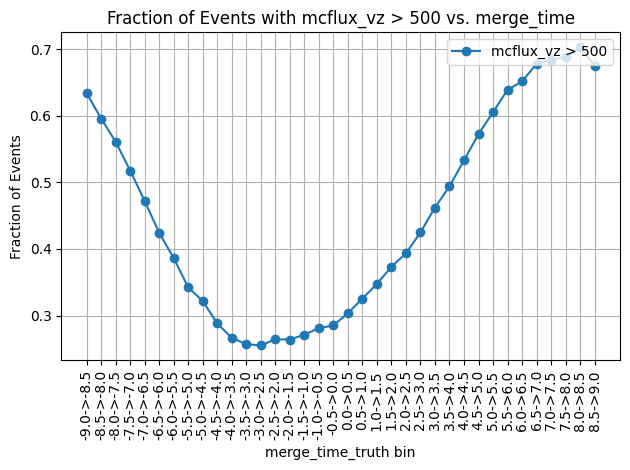

In [ ]:
bin_edges = np.arange(-9, 9, 0.5)
xticks = [f"{round(i,1)}->{round(i+0.5,1)}" for i in bin_edges]

fractions = []
for i in bin_edges:
    cut = f"merge_time > {i} and merge_time < {i+0.5}"
    df_cut = nu_overlay_run4_super_df.query(cut)
    total = len(df_cut)
    if total > 0:
        passing = len(df_cut.query("mcflux_vz > 500"))
        fraction = passing / total
    else:
        fraction = np.nan
    fractions.append(fraction)

plt.figure()
plt.plot(xticks, fractions, marker='o', label="mcflux_vz > 500")
plt.xticks(rotation=90)
plt.ylabel("Fraction of Events")
plt.xlabel("merge_time_truth bin")
plt.title("Fraction of Events with mcflux_vz > 500 vs. merge_time")
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

Variable: kine_reco_Enu
  Selection: off target
    Median: 766.4892578125, Count: 45706
  Selection: on target
    Median: 853.8602294921875, Count: 73581
Variable: Ehadron
  Selection: off target
    Median: 377.4200439453125, Count: 45706
  Selection: on target
    Median: 457.27569580078125, Count: 73581
Variable: reco_nu_numi_theta
  Selection: off target
    Median: 0.541082974663666, Count: 35248
  Selection: on target
    Median: 0.5296272156935111, Count: 56264


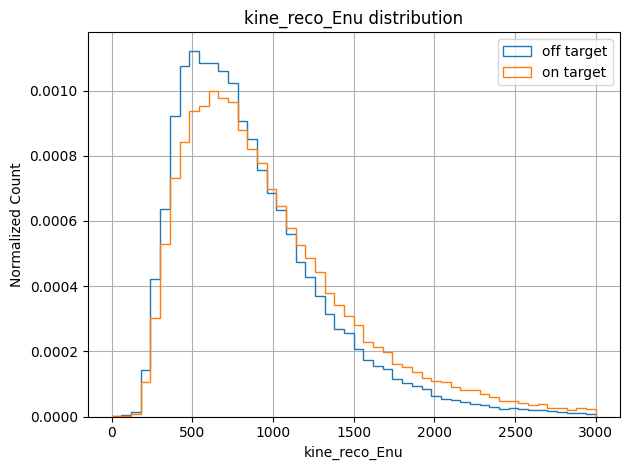

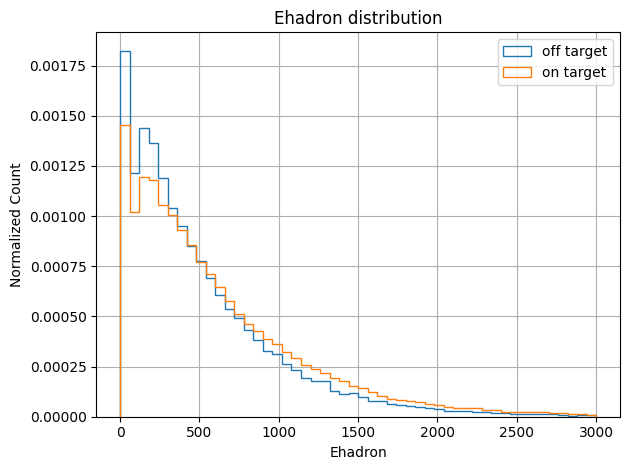

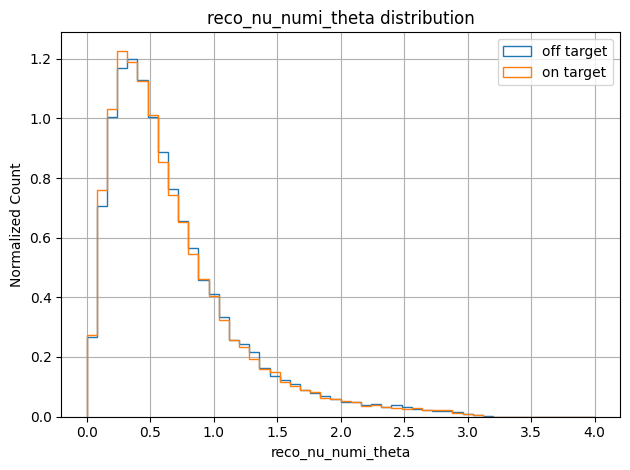

In [ ]:
def pretty_label(sel: str) -> str:
    s = " ".join(sel.split())
    if "mcflux_vz<500" in s:
        return "on target"
    if "mcflux_vz>500" in s:
        return "off target"
    return sel

variables_to_hist_slim = [
    "kine_reco_Enu", "Ehadron", "reco_nu_numi_theta"
]
plot_subsection = "numu_score > 0.9 or sel_numuCC_1mu1p==True or nue_score > 7" or CCpi0_query or NCpi0_query
selections = [
    f"(mcflux_vz>500) and {plot_subsection}",
    f"(mcflux_vz<500) and {plot_subsection}",
]

custom_bins = {
    "kine_reco_Enu": np.linspace(0, 3000, 51),
    "Ehadron": np.linspace(0, 3000, 51),
    "reco_nu_numi_theta": np.linspace(0, 4, 51)
}

for var in variables_to_hist_slim:
    print(f"Variable: {var}")
    for sel in selections:
        data = nu_overlay_run4_super_df.query(sel)[var].dropna()
        data = data[~data.isin([-999, -9999, -1000])]
        median_val = float(np.median(data)) if len(data) else np.nan
        print(f"  Selection: {pretty_label(sel)}\n    Median: {median_val}, Count: {len(data)}")

for var in variables_to_hist_slim:
    plt.figure()
    if var in custom_bins:
        bins = custom_bins[var]
    else:
        all_data = nu_overlay_run4_super_df.query(selections[0])[var].dropna()
        all_data = all_data[~all_data.isin([-999, -9999, -1000])]
        if len(all_data) == 0:
            continue
        bins = np.linspace(all_data.min(), all_data.max(), 51)

    for sel in selections:
        data = nu_overlay_run4_super_df.query(sel)[var].dropna()
        data = data[~data.isin([-999, -9999, -1000])]
        if len(data) == 0:
            continue
        plt.hist(data, bins=bins, histtype='step', density=True, label=pretty_label(sel))

    plt.title(f"{var} distribution")
    plt.xlabel(var)
    plt.ylabel("Normalized Count")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


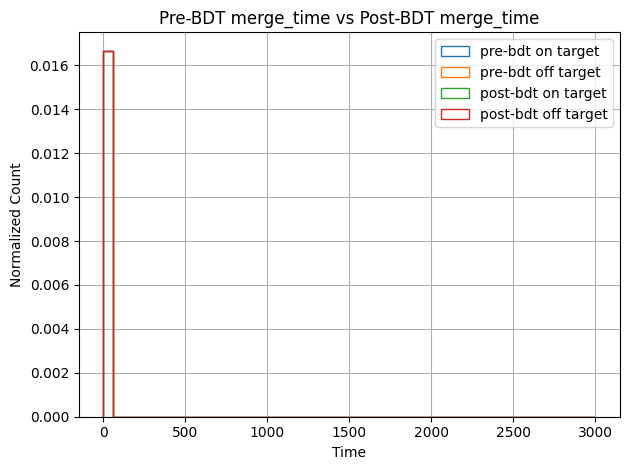

Variable: truth_nuEnergy (after BDT cut > 0.6)


UndefinedVariableError: name 'score_mcflux_vz_gt500' is not defined

In [ ]:
# Apply BDT classification cut
bdt_cut_threshold = 0.6

def pretty_label(sel: str) -> str:
    s = " ".join(sel.split())
    if "mcflux_vz<500" in s:
        return "on target"
    elif "mcflux_vz>500" in s:
        return "off target"
    else:
        return sel

variables_to_hist_slim = [
    "truth_nuEnergy", "Ehadron", "reco_nu_numi_theta"
]

custom_bins = {
    "truth_nuEnergy": np.linspace(0, 3000, 51),
    "Ehadron": np.linspace(0, 3000, 51),
    "reco_nu_numi_theta": np.linspace(0, 4, 51)
}

bins = np.linspace(0, 3000, 51)

pre_selections = [
    f"(mcflux_vz>500) and ({plot_subsection})",
    f"(mcflux_vz<500) and ({plot_subsection})",
]

post_selections = [
    f"(mcflux_vz>500) and {bdt_score_name} > {bdt_cut_threshold} and ({plot_subsection})",
    f"(mcflux_vz<500) and {bdt_score_name} > {bdt_cut_threshold} and ({plot_subsection})",
]

plt.figure()

# Pre-BDT: kine_reco_Enu from full df
for sel, tag in zip(pre_selections, ["on target", "off target"]):
    data = nu_overlay_run4_super_df.query(sel)["kine_reco_Enu"].dropna()
    data = data[~data.isin([-999, -9999, -1000])]
    if len(data):
        plt.hist(data, bins=bins, histtype="step", density=True,
                 label=f"pre-bdt {tag}")

# Post-BDT: truth_nuEnergy from test df
for sel, tag in zip(post_selections, ["on target", "off target"]):
    data = test_df.query(sel)["kine_reco_Enu"].dropna()
    data = data[~data.isin([-999, -9999, -1000])]
    if len(data):
        plt.hist(data, bins=bins, histtype="step", density=True,
                 label=f"post-bdt {tag}")

plt.title("Pre-BDT kine_reco_Enu vs Post-BDT truth_nuEnergy")
plt.xlabel("Energy (MeV)")
plt.ylabel("Normalized Count")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print statistics with BDT cut applied
for var in variables_to_hist_slim:
    print(f"Variable: {var} (after BDT cut > {bdt_cut_threshold})")
    for sel in selections:
        # Use test_df since it has the BDT scores
        data = test_df.query(sel)[var].dropna()
        data = data[~data.isin([-999, -9999, -1000])]
        median_val = float(np.median(data)) if len(data) else np.nan
        print(f"  Selection: {pretty_label(sel)}\n    Median: {median_val}, Count: {len(data)}")

# Plot distributions with BDT cut applied
for var in variables_to_hist_slim:
    plt.figure()
    if var in custom_bins:
        bins = custom_bins[var]
    else:
        all_data = test_df.query(selections[0])[var].dropna()
        all_data = all_data[~all_data.isin([-999, -9999, -1000])]
        if len(all_data) == 0:
            continue
        bins = np.linspace(all_data.min(), all_data.max(), 51)

    for sel in selections:
        data = test_df.query(sel)[var].dropna()
        data = data[~data.isin([-999, -9999, -1000])]
        if len(data) == 0:
            continue
        plt.hist(data, bins=bins, histtype='step', density=True, label=pretty_label(sel))

    plt.title(f"{var} distribution (BDT score > {bdt_cut_threshold})")
    plt.xlabel(var)
    plt.ylabel("Normalized Count")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

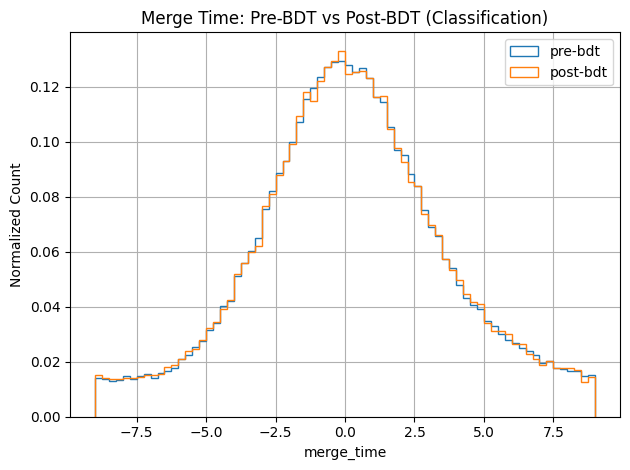

In [ ]:
# ---- Classification BDT: merge_time pre vs post ----
bdt_cut_threshold = 0.7
bins_mt = np.linspace(-9, 9, 73)

pre_sel_cls = f"{plot_subsection}"
post_sel_cls = f"{plot_subsection} and {bdt_score_name} > {bdt_cut_threshold}"

plt.figure()

# Pre-BDT: merge_time from full df
data_pre = nu_overlay_run4_super_df.query(pre_sel_cls)["merge_time"].dropna()
data_pre = data_pre[~data_pre.isin([-999, -9999, -1000])]
if len(data_pre):
    plt.hist(data_pre, bins=bins_mt, histtype="step", density=True, label="pre-bdt")

# Post-BDT: merge_time from test df (classification scores)
data_post = test_df.query(post_sel_cls)["merge_time"].dropna()
data_post = data_post[~data_post.isin([-999, -9999, -1000])]
if len(data_post):
    plt.hist(data_post, bins=bins_mt, histtype="step", density=True, label="post-bdt")

plt.title("Merge Time: Pre-BDT vs Post-BDT (Classification)")
plt.xlabel("merge_time")
plt.ylabel("Normalized Count")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
'''import os

name='newbdt/flux_vz_gt500'

if os.path.exists(name+'.json'):
    print(name+'.json exists, exiting')
else:
    model_kp1540_proton_more.save_model(name+'.json')'''

"import os\n\nname='newbdt/flux_vz_gt500'\n\nif os.path.exists(name+'.json'):\n    print(name+'.json exists, exiting')\nelse:\n    model_kp1540_proton_more.save_model(name+'.json')"

# Regression BDT (vz)

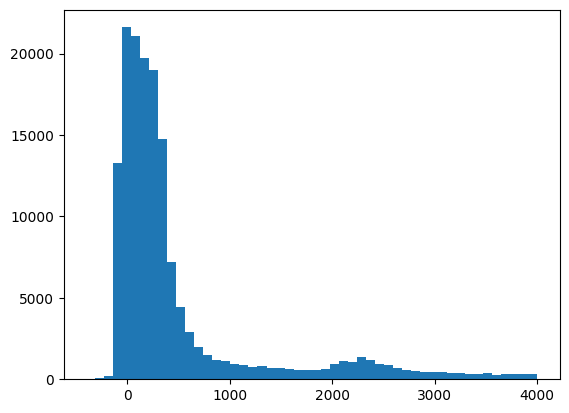

  0% : -379.94305419921875
 10% : -25.55144691467285
 20% : 52.58689880371094
 30% : 132.76898956298828
 40% : 217.94252014160156
 50% : 306.7100830078125
 60% : 446.0984191894531
 70% : 1398.3843383789062
 80% : 4409.20361328125
 90% : 15262.318359375
100% : 74042.8671875


In [ ]:
plt.hist(nu_overlay_run4_super_df['mcflux_vz'], range=(-400,4000), bins=50)
plt.show()
vz = nu_overlay_run4_super_df["mcflux_vz"].dropna()
deciles = np.percentile(vz, np.arange(0, 101, 10))
for p, v in zip(range(0, 101, 10), deciles):
    print(f"{p:>3}% : {v}")

In [ ]:
# What is the subset of events you want to be training on, should include both "signal and background"
#clean selection: sel_numuCC_1mu1p==True
true_query = "index >= 0"
reco_query = "index >= 0"
# Creating a dataframe with 50%
# values of original dataframe
fraction = 0.5
temp_df = nu_overlay_run4_super_df.query(true_query).query(reco_query)
temp_df = temp_df.reset_index()
train_df = temp_df.sample(frac = fraction)
test_df = temp_df.drop(train_df.index)

In [ ]:
# What is the name of the BDT variable you will be making
bdt_score_name = "score_mcflux_vz"
# Define what variables your BDT is going to be using for prediction
train_vars_more = [
    'reco_nu_numi_phi',
    'reco_nu_numi_theta',

    'reco_Eproton',
    'reco_Emuon',
    'kine_reco_Enu',
    'Ehadron',

    'kine_reco_add_energy',
    'reco_nuvtxX',
    'reco_nuvtxY',
    'reco_nuvtxZ',

    'kine_pio_flag', 'kine_pio_mass', 'kine_pio_vtx_dis', 'kine_pio_angle',

    'merge_time',

    'reco_muon_costheta',
    'reco_track_theta',
    'reco_Ntrack',
    'reco_Nproton'
]
# How many of these we will "downselect" to in the final BDT, high number means just use all of them
num_vars = 300
# Define what variable your BDT is going to trying to predict
target_var = "mcflux_vz_gt0"
# Go to an even small subset of the data just for the training if you desire
further_subset_query = "mcflux_vz < 18000"

# Number of rounds to train for
n = 150
# Define the hyperparameter distributions, these will be optimized in this regime in the BDT training
param_dist = {
    'max_depth': stats.randint(3, 6),
    'eta': stats.uniform(0.05, 0.10),
    'min_child_weight': stats.uniform(4, 8),
    'gamma': stats.uniform(0.2, 2),
    'lambda': stats.uniform(0.5, 4.5),
    'alpha': stats.uniform(0.0, 1.0),
    'subsample': stats.uniform(0.6, 0.4),
    'colsample_bytree': stats.uniform(0.7, 0.3)
}

train_df["mcflux_vz_gt0"] = (train_df["mcflux_vz"]).clip(0)
test_df["mcflux_vz_gt0"] = (test_df["mcflux_vz"]).clip(0)

# Extract feature and target arrays
X_test = test_df.query(further_subset_query)[train_vars_more].copy()
X_train = train_df.query(further_subset_query)[train_vars_more].copy()
y_test = test_df.query(further_subset_query)[[target_var]].copy()
y_train = train_df.query(further_subset_query)[[target_var]].copy()

# ---------- Build consistent X/y ----------
X_train_df = train_df.query(further_subset_query).fillna(0)[train_vars_more].copy()
y_train = np.log1p(train_df.query(further_subset_query)[target_var].values)

X_test_df  = test_df.query(further_subset_query).fillna(0)[train_vars_more].copy()
y_test = np.log1p(test_df.query(further_subset_query)[target_var].values)

# ---------- Feature preselection ----------
k = min(num_vars, X_train_df.shape[1])  # guard against k > n_features
presel = SelectKBest(f_regression, k=k).fit(X_train_df, y_train)

feat_names = list(X_train_df.columns[presel.get_support()])

X_train = presel.transform(X_train_df)
X_test  = presel.transform(X_test_df)

# ---------- Hyperparameter tuning ----------
xgb_model = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=n,
    tree_method="hist",   # usually faster
    random_state=0
)

random_search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_dist,
    n_iter=100,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1,
    random_state=0
)
random_search.fit(X_train, y_train)

best_params = random_search.best_params_
print("Best set of hyperparameters: ", best_params)
print("Best score: ", random_search.best_score_)

# ---------- Train final booster with eval curves ----------
final_params = dict(best_params)
final_params["objective"] = "reg:squarederror"

dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=feat_names)
dtest  = xgb.DMatrix(X_test,  label=y_test,  feature_names=feat_names)

evals = [(dtest, "validation"), (dtrain, "train")]
evals_result = {}

model_score_kp_proton_Kp = xgb.train(
    params=final_params,
    dtrain=dtrain,
    num_boost_round=n,
    evals=evals,
    evals_result=evals_result,
    verbose_eval=50
)

# ---------- Predict on FULL dfs consistently ----------
def add_pred(df, out_name):
    X_df = df.fillna(0)[train_vars_more].copy()
    X_mat = presel.transform(X_df)
    dmat = xgb.DMatrix(X_mat, feature_names=feat_names)
    df[out_name] = np.expm1(model_score_kp_proton_Kp.predict(dmat))

add_pred(test_df, bdt_score_name)
add_pred(train_df, bdt_score_name)



C:\Users\andre\AppData\Local\Temp\ipykernel_2708\2704880117.py:58: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train_df = train_df.query(further_subset_query).fillna(0)[train_vars_more].copy()
C:\Users\andre\AppData\Local\Temp\ipykernel_2708\2704880117.py:61: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test_df  = test_df.query(further_subset_query).fillna(0)[train_vars_more].copy()


Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best set of hyperparameters:  {'alpha': np.float64(0.24465141426217707), 'colsample_bytree': np.float64(0.8122969589911662), 'eta': np.float64(0.054565964198897844), 'gamma': np.float64(0.8201352799378994), 'lambda': np.float64(4.241837299424617), 'max_depth': 4, 'min_child_weight': np.float64(9.120193242395507), 'subsample': np.float64(0.7472409607926136)}
Best score:  -2.0133753299713133
[0]	validation-rmse:2.72131	train-rmse:2.71022
[50]	validation-rmse:2.64098	train-rmse:2.62247
[100]	validation-rmse:2.63464	train-rmse:2.60868
[149]	validation-rmse:2.63355	train-rmse:2.60024


C:\Users\andre\AppData\Local\Temp\ipykernel_2708\2704880117.py:118: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_df = df.fillna(0)[train_vars_more].copy()
C:\Users\andre\AppData\Local\Temp\ipykernel_2708\2704880117.py:118: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_df = df.fillna(0)[train_vars_more].copy()


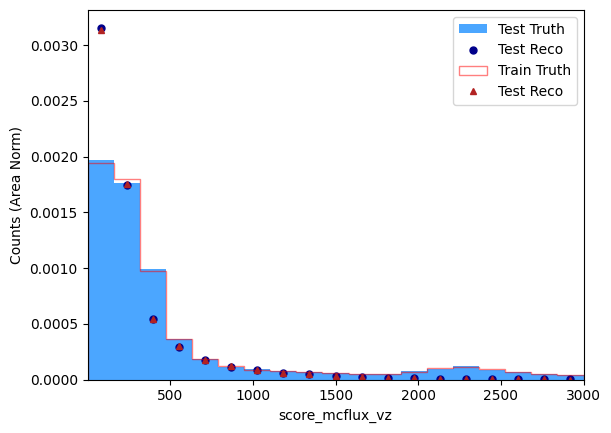

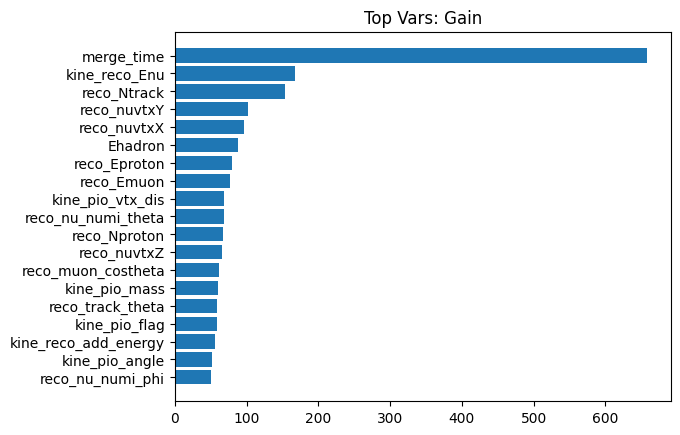

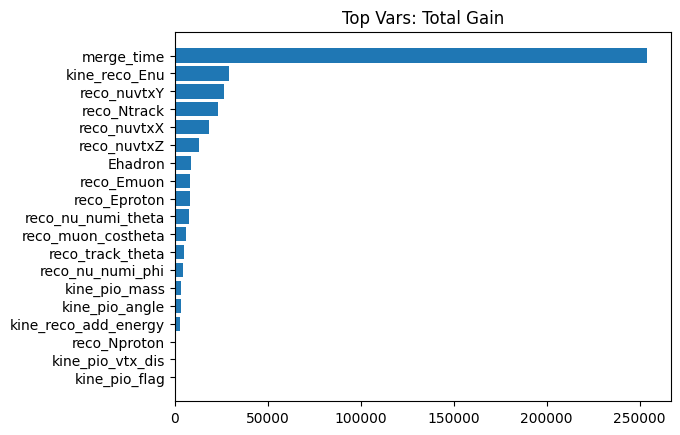

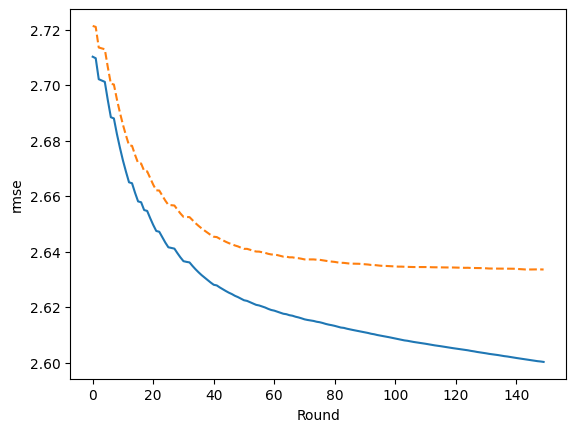

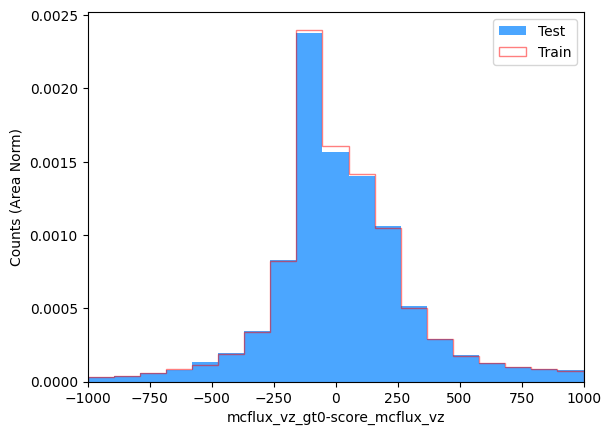

C:\Users\andre\AppData\Local\Temp\ipykernel_2708\2469192536.py:82: RuntimeWarning: divide by zero encountered in divide
  plt.hist((test_df[target_var].to_numpy()-test_df[bdt_score_name].to_numpy())/test_df[target_var].to_numpy(),bins=bins,density=True,alpha=0.8,color="dodgerblue",label="Test")
C:\Users\andre\AppData\Local\Temp\ipykernel_2708\2469192536.py:83: RuntimeWarning: divide by zero encountered in divide
  plt.hist((train_df[target_var].to_numpy()-train_df[bdt_score_name].to_numpy())/train_df[target_var].to_numpy(),bins=bins,density=True,alpha=0.5,color="red",label="Train",histtype="step")


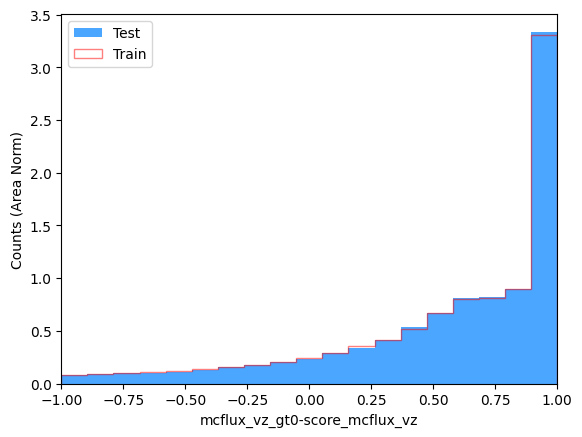

In [ ]:
plotit = True
plotit_diff = True
plotit_frac = True
plot_importance = True
max_items = 20
plot_loss = True
plot_eff = True

#for plotting your output variable predictions
minx = 0.1
maxx = 3000
diff_minx = -1000
diff_maxx = 1000
frac_minx = -1
frac_maxx = 1

# Makes a plot of the score for signal and background
# Hopefuly you see good reco and true agreement here
# Also good to see similar performansce on test versus train
if plotit:    
    bins = np.linspace(minx, maxx, num=20)     
    y_reco_test,x = np.histogram(test_df[bdt_score_name].to_numpy(),bins=bins,density=True)
    y_reco_train,x = np.histogram(train_df[bdt_score_name].to_numpy(),bins=bins,density=True)   
    plt.figure()
    plt.hist(test_df[target_var].to_numpy(),bins=bins,density=True,alpha=0.8,color="dodgerblue",label="Test Truth")
    plt.plot(get_bin_centers(x),y_reco_test,color="darkblue",marker="o",ms=5,lw=0,label="Test Reco")
    plt.hist(train_df[target_var].to_numpy(),bins=bins,density=True,alpha=0.5,color="red",label="Train Truth",histtype="step")
    plt.plot(get_bin_centers(x),y_reco_train,marker="^",ms=5,lw=0,color="firebrick",label="Test Reco")
    plt.legend()
    plt.xlim(minx,maxx)
    plt.xlabel(bdt_score_name)
    plt.ylabel("Counts (Area Norm)")
    plt.show()

# Scores telling you which variables are being used by the BDT
if plot_importance:
    # Gain tells you the "local importance", when used to make a decision, how good is the variable?
    importance = model_score_kp_proton_Kp.get_score(importance_type='gain')
    full_lists = sorted(importance.items(), key=lambda x: x[1]) 
    if(len(full_lists)>max_items): lists = full_lists[len(full_lists)-max_items:]
    else: lists = full_lists
    x, y = zip(*lists) # unpack a list of pairs into two tuples
    plt.title("Top Vars: Gain")
    plt.barh(x,y)
    plt.show()
    
    # Total Gain tells you the "global importance", aggregated over all decisions, how good is the variable?
    importance = model_score_kp_proton_Kp.get_score(importance_type='total_gain')
    full_lists = sorted(importance.items(), key=lambda x: x[1]) 
    if(len(full_lists)>max_items): lists = full_lists[len(full_lists)-max_items:]
    else: lists = full_lists    
    x, y = zip(*lists) # unpack a list of pairs into two tuples
    plt.title("Top Vars: Total Gain")
    plt.barh(x,y)
    plt.show()

#Show test and training rmse 
if plot_loss:
    x = np.linspace(1,n,n)
    plt.figure()
    plt.plot(evals_result['train']['rmse'],label='train')
    plt.plot(evals_result['validation']['rmse'],label='test',ls='--')
    plt.ylabel("rmse")
    plt.xlabel("Round")
    plt.show()


if plotit_diff:    
    bins = np.linspace(diff_minx,diff_maxx, num=20)     
    plt.figure()
    plt.hist(test_df[target_var].to_numpy()-test_df[bdt_score_name].to_numpy(),bins=bins,density=True,alpha=0.8,color="dodgerblue",label="Test")
    plt.hist(train_df[target_var].to_numpy()-train_df[bdt_score_name].to_numpy(),bins=bins,density=True,alpha=0.5,color="red",label="Train",histtype="step")
    plt.legend()
    plt.xlim(diff_minx,diff_maxx)
    plt.xlabel(target_var+"-"+bdt_score_name)
    plt.ylabel("Counts (Area Norm)")
    plt.show()

if plotit_frac:    
    bins = np.linspace(frac_minx,frac_maxx, num=20)     
    plt.figure()
    plt.hist((test_df[target_var].to_numpy()-test_df[bdt_score_name].to_numpy())/test_df[target_var].to_numpy(),bins=bins,density=True,alpha=0.8,color="dodgerblue",label="Test")
    plt.hist((train_df[target_var].to_numpy()-train_df[bdt_score_name].to_numpy())/train_df[target_var].to_numpy(),bins=bins,density=True,alpha=0.5,color="red",label="Train",histtype="step")
    plt.legend()
    plt.xlim(frac_minx,frac_maxx)
    plt.xlabel(target_var+"-"+bdt_score_name)
    plt.ylabel("Counts (Area Norm)")
    plt.show()

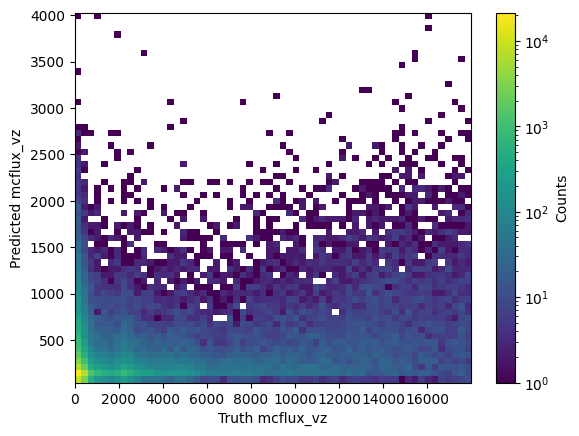

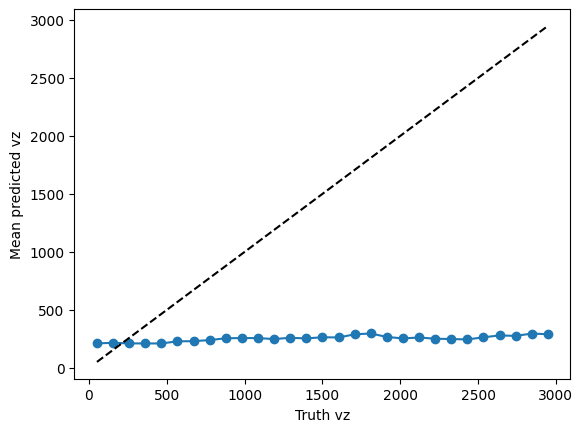

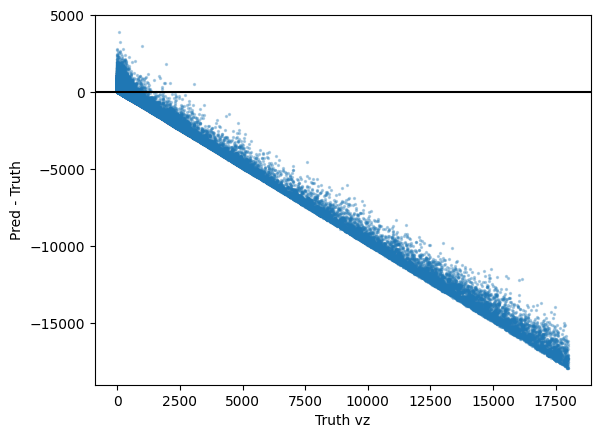

In [ ]:
from matplotlib.colors import LogNorm

mask_df = test_df.query(further_subset_query)
y_test_raw = mask_df[target_var].values
y_pred = mask_df[bdt_score_name].values

plt.hist2d(
    y_test_raw,
    y_pred,
    bins=60,
    norm=LogNorm()
)
plt.xlabel("Truth mcflux_vz")
plt.ylabel("Predicted mcflux_vz")
plt.colorbar(label="Counts")
plt.show()

bins = np.linspace(0, 3000, 30)
digitized = np.digitize(y_test_raw, bins)

bin_centers = 0.5 * (bins[:-1] + bins[1:])
means = [
    np.mean(y_pred[digitized == i])
    for i in range(1, len(bins))
]

plt.plot(bin_centers, means, marker='o')
plt.plot(bin_centers, bin_centers, 'k--')
plt.xlabel("Truth vz")
plt.ylabel("Mean predicted vz")
plt.show()

plt.scatter(
    y_test_raw,
    y_pred - y_test_raw,
    s=2,
    alpha=0.3
)
plt.axhline(0, color='k')
plt.xlabel("Truth vz")
plt.ylabel("Pred - Truth")
plt.show()



## Multi-Classification

In [14]:
# ORDINAL (JOINT CUMULATIVE) MODEL: single shared XGB classifier

bdt_score_name = "score_mcflux_vz_prism"        # single combined score per event
bdt_bin_name   = "pred_mcflux_vz_prism_bin"     # optional discrete bin 0..K-1
train_vars_more = train_vars_slim
num_vars = 30
further_subset_query = reco_query

# bin edges (K = len(edges)+1 ordinal bins)
edges = [500, 7500, 10000]
K = len(edges) + 1          # number of bins
T = len(edges)              # number of thresholds = K-1

# training rounds
n = 200

# hyperparameter search space (sklearn param names)
param_dist = {
    'max_depth': stats.randint(3, 10),
    'learning_rate': stats.uniform(0.01, 0.3),
    'gamma': stats.uniform(0, 5),
    'reg_lambda': stats.uniform(0, 3),
    'reg_alpha': stats.uniform(0, 3),
    'min_child_weight': stats.uniform(1, 9),
    'subsample': stats.uniform(0.6, 0.4),
    'colsample_bytree': stats.uniform(0.6, 0.4),
    'colsample_bylevel': stats.uniform(0.6, 0.4),
}

# ----------------------------
# FEATURES: build X_train/X_test once
# ----------------------------
X_test  = test_df.query(further_subset_query)[train_vars_more].copy()
X_train = train_df.query(further_subset_query)[train_vars_more].copy()

# Convert awkward arrays to scalar values BEFORE fillna (your logic, generalized)
def _to_scalar(x):
    if isinstance(x, (list, tuple, np.ndarray)) and len(x) > 0:
        return float(x[0])
    else:
        return 0.0

for col in X_train.columns:
    try:
        if hasattr(X_train[col].iloc[0], "__len__") and not isinstance(X_train[col].iloc[0], str):
            X_train[col] = X_train[col].apply(_to_scalar)
            X_test[col]  = X_test[col].apply(_to_scalar)
    except (TypeError, IndexError, AttributeError):
        X_train[col] = 0.0
        X_test[col]  = 0.0

X_train = X_train.fillna(0).astype(float).replace([np.inf, -np.inf], 0.0)
X_test  = X_test.fillna(0).astype(float).replace([np.inf, -np.inf], 0.0)

# ----------------------------
# LABELS: ordinal bin label 0..K-1 (derived from mcflux_vz)
# ----------------------------
train_df.loc[train_df.query(further_subset_query).index, "vz_bin"] = np.digitize(
    train_df.query(further_subset_query)["mcflux_vz"].values, bins=np.array(edges), right=False
).astype(int)

test_df.loc[test_df.query(further_subset_query).index, "vz_bin"] = np.digitize(
    test_df.query(further_subset_query)["mcflux_vz"].values, bins=np.array(edges), right=False
).astype(int)

y_train_bins = train_df.query(further_subset_query)["vz_bin"].astype(int).values
y_test_bins  = test_df.query(further_subset_query)["vz_bin"].astype(int).values

# ----------------------------
# FEATURE SELECTION: do it once using ordinal bin labels (fixes middle-bin bias)
# ----------------------------
presel = SelectKBest(f_classif, k=num_vars).fit(X_train, y_train_bins)

new_names = list(presel.get_feature_names_out())
X_train_sel = presel.transform(X_train)
X_test_sel  = presel.transform(X_test)

# ----------------------------
# ORDINAL EXPANSION: build joint cumulative training set
# z_{i,k} = 1 if y_i >= (k+1) else 0, with added feature thr=k
# ----------------------------
def make_ordinal_expanded(X_sel, y_bins, T):
    """
    X_sel: (N, d)
    y_bins: (N,) in {0..K-1}
    Returns:
      X_exp: (N*T, d+1) last col = thr index (0..T-1)
      z_exp: (N*T,) binary label: 1 if y >= (thr+1)
      k_rep: (N*T,) threshold index per row (int)
    """
    N, d = X_sel.shape
    X_rep = np.repeat(X_sel, T, axis=0)  # (N*T, d)

    k_rep = np.tile(np.arange(T, dtype=int), N)      # (N*T,)
    thr   = k_rep.astype(float).reshape(-1, 1)       # numeric feature

    y_rep = np.repeat(y_bins, T)
    z_exp = (y_rep >= (k_rep + 1)).astype(int)

    X_exp = np.hstack([X_rep, thr])                  # (N*T, d+1)
    return X_exp, z_exp, k_rep

X_train_exp, z_train_exp, krep_train = make_ordinal_expanded(X_train_sel, y_train_bins, T)
X_test_exp,  z_test_exp,  krep_test  = make_ordinal_expanded(X_test_sel,  y_test_bins,  T)

# ----------------------------
# OPTIONAL IMBALANCE WEIGHTING PER THRESHOLD (recommended)
# weight positives more for each threshold k
# ----------------------------
w_train_exp = np.ones_like(z_train_exp, dtype=float)
for k in range(T):
    mask = (krep_train == k)
    n_pos = float(z_train_exp[mask].sum())
    n_tot = float(mask.sum())
    n_neg = n_tot - n_pos
    spw = (n_neg / n_pos) if n_pos > 0 else 1.0
    w_train_exp[mask & (z_train_exp == 1)] = spw

# ----------------------------
# TRAIN: one joint binary model with monotone constraint on "thr"
# thr constraint = -1 enforces p(y>=k+1) decreases with increasing k
# ----------------------------
mono = "(" + ",".join(["0"] * len(new_names) + ["-1"]) + ")"

base_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",          # probability-quality metric (better than AUC here)
    n_estimators=n,
    monotone_constraints=mono,
)

random_search = RandomizedSearchCV(
    base_model,
    param_distributions=param_dist,
    n_iter=60,
    cv=5,
    scoring="neg_log_loss",
    verbose=0
)

random_search.fit(X_train_exp, z_train_exp, sample_weight=w_train_exp)
ord_model = random_search.best_estimator_

print("\n=== JOINT ORDINAL MODEL ===")
print("Best params:", random_search.best_params_)
print("Best CV neg_log_loss:", random_search.best_score_)

# ----------------------------
# PREDICT: get cumulative threshold probs p_k = P(y >= k+1 | X)
# Reshape from (N*T,) -> (N, T)
# ----------------------------
p_train_exp = ord_model.predict_proba(X_train_exp)[:, 1]
p_test_exp  = ord_model.predict_proba(X_test_exp)[:, 1]

Ntr = X_train_sel.shape[0]
Nte = X_test_sel.shape[0]
p_train = p_train_exp.reshape(Ntr, T)
p_test  = p_test_exp.reshape(Nte, T)

# Monotonic clamp (should already hold with constraint, but keep safe)
def enforce_monotone_matrix(p_mat):
    p = p_mat.copy()
    for k in range(1, p.shape[1]):
        p[:, k] = np.minimum(p[:, k], p[:, k-1])
    return np.clip(p, 0.0, 1.0)

p_train = enforce_monotone_matrix(p_train)
p_test  = enforce_monotone_matrix(p_test)

# ----------------------------
# BIN PROBS: derive P(bin j) from cumulative probs
# bins are 0..K-1, thresholds are edges[0..T-1]
# ----------------------------
def bins_from_cumulative(p_mat):
    # p_mat shape (N, T) with p[:,k] = P(y >= k+1)
    N, T = p_mat.shape
    K = T + 1
    P = np.zeros((N, K), dtype=float)

    P[:, 0] = 1.0 - p_mat[:, 0]
    for j in range(1, T):
        P[:, j] = p_mat[:, j-1] - p_mat[:, j]
    P[:, K-1] = p_mat[:, T-1]

    P = np.clip(P, 0.0, 1.0)
    s = P.sum(axis=1, keepdims=True)
    s[s == 0] = 1.0
    return P / s

Pbins_train = bins_from_cumulative(p_train)
Pbins_test  = bins_from_cumulative(p_test)

# ----------------------------
# SINGLE COMBINED SCORE: expected bin index (0..K-1)
# ----------------------------
bin_ids = np.arange(K, dtype=float)

train_idx = train_df.query(further_subset_query).index
test_idx  = test_df.query(further_subset_query).index

train_df.loc[train_idx, bdt_score_name] = (Pbins_train * bin_ids).sum(axis=1)
test_df.loc[test_idx,  bdt_score_name] = (Pbins_test  * bin_ids).sum(axis=1)

# Optional discrete bin label
train_df.loc[train_idx, bdt_bin_name] = np.argmax(Pbins_train, axis=1)
test_df.loc[test_idx,  bdt_bin_name] = np.argmax(Pbins_test, axis=1)

# Optional: store per-bin probs
for j in range(K):
    train_df.loc[train_idx, f"p_prism_bin{j}"] = Pbins_train[:, j]
    test_df.loc[test_idx,  f"p_prism_bin{j}"] = Pbins_test[:, j]

print("\nDone. Added:")
print(" -", bdt_score_name, f"(single combined scalar score ~ expected bin index 0..{K-1})")
print(" -", bdt_bin_name,   f"(argmax bin label 0..{K-1})")
print(f" - p_prism_bin0..{K-1}   (optional probabilities for weighting)")


c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [13 14 15 16] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



=== JOINT ORDINAL MODEL ===
Best params: {'colsample_bylevel': np.float64(0.9727575345206864), 'colsample_bytree': np.float64(0.77541179951969), 'gamma': np.float64(2.972194239138315), 'learning_rate': np.float64(0.023800764265548058), 'max_depth': 7, 'min_child_weight': np.float64(9.422382784314939), 'reg_alpha': np.float64(2.5369769459288207), 'reg_lambda': np.float64(1.1451801188571902), 'subsample': np.float64(0.7820853303538545)}
Best CV neg_log_loss: -0.5664846393464945

Done. Added:
 - score_mcflux_vz_prism (single combined scalar score ~ expected bin index 0..3)
 - pred_mcflux_vz_prism_bin (argmax bin label 0..3)
 - p_prism_bin0..3   (optional probabilities for weighting)


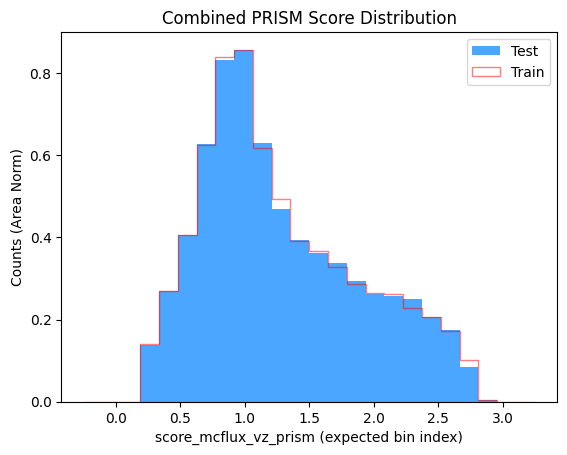

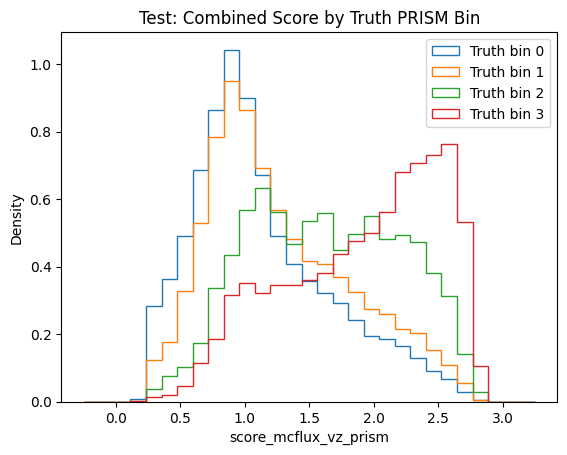

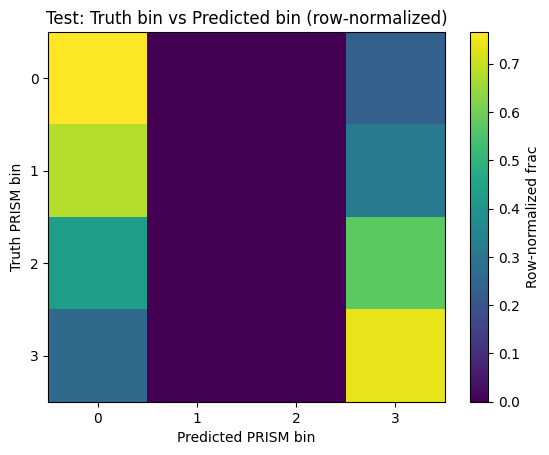

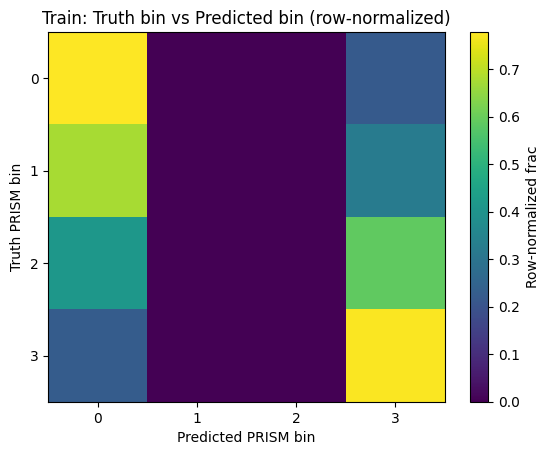

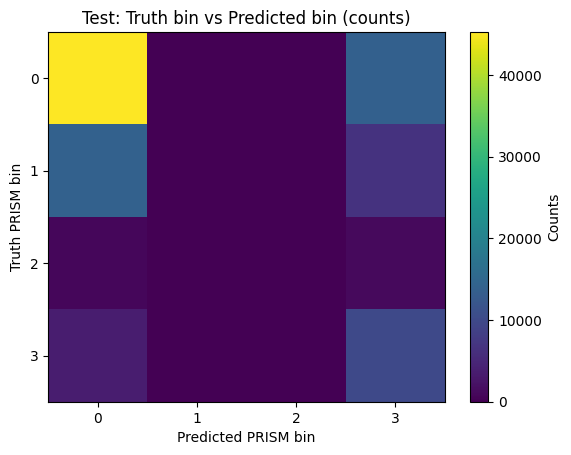

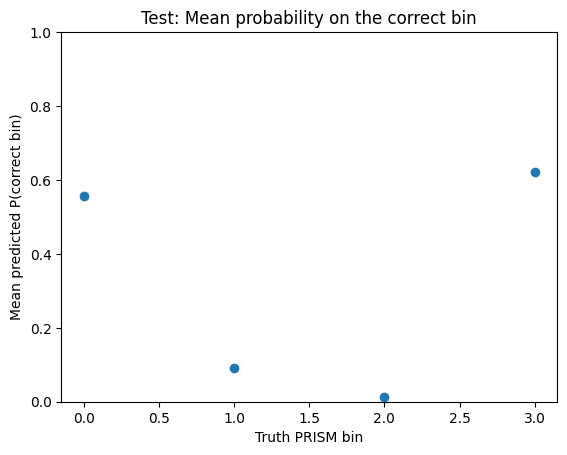

NameError: name 'models_by_t' is not defined

In [16]:

plot_score_by_bin = True
plot_migration = True
plot_score_only = True
plot_threshold_rocs = False      # set True if you want ROC curves
plot_importance = True
max_items = 20
plot_loss = True                # now plots AUC/logloss per threshold

def get_bin_centers(edges):
    return 0.5*(edges[1:]+edges[:-1])

def prism_truth_bin(vz, edges):
    # returns 0..len(edges)
    # bins: <e0, e0-e1, e1-e2, ..., >=e_last
    return np.digitize(vz, bins=np.array(edges), right=False)

def confusion_matrix(truth, pred, ncls):
    cm = np.zeros((ncls, ncls), dtype=int)
    for t, p in zip(truth, pred):
        if 0 <= t < ncls and 0 <= p < ncls:
            cm[t, p] += 1
    return cm

def plot_cm(cm, title="Migration Matrix", normalize=True):
    cm_plot = cm.astype(float)
    if normalize:
        row_sums = cm_plot.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        cm_plot = cm_plot / row_sums

    plt.figure()
    plt.imshow(cm_plot, aspect='auto')
    plt.colorbar(label="Row-normalized frac" if normalize else "Counts")
    plt.xlabel("Predicted PRISM bin")
    plt.ylabel("Truth PRISM bin")
    plt.title(title)
    plt.xticks(range(cm.shape[1]))
    plt.yticks(range(cm.shape[0]))
    plt.show()


# -------- Define truth bins for train/test --------
n_bins = len(edges) + 1

truth_bin_test  = prism_truth_bin(test_df["mcflux_vz"].to_numpy(), edges)
truth_bin_train = prism_truth_bin(train_df["mcflux_vz"].to_numpy(), edges)

# predicted bins (from earlier combined pipeline)
pred_bin_test  = test_df[bdt_bin_name].to_numpy().astype(int)
pred_bin_train = train_df[bdt_bin_name].to_numpy().astype(int)


# ==========================================================
# 1) Combined score distribution (single scalar 0..4)
# ==========================================================
if plot_score_only:
    bins = np.linspace(-0.25, n_bins-0.75, 25)  # around 0..4
    plt.figure()
    plt.hist(test_df[bdt_score_name].to_numpy(), bins=bins, density=True, label="Test", alpha=0.8,color="dodgerblue", histtype="stepfilled")
    plt.hist(train_df[bdt_score_name].to_numpy(), bins=bins, density=True, label="Train", alpha=0.5,color='red', histtype="step")
    plt.xlabel(bdt_score_name + " (expected bin index)")
    plt.ylabel("Counts (Area Norm)")
    plt.title("Combined PRISM Score Distribution")
    plt.legend()
    plt.show()


# ==========================================================
# 2) Score distribution *by truth bin* (does it separate bins?)
# ==========================================================
if plot_score_by_bin:
    bins = np.linspace(-0.25, n_bins-0.75, 30)
    plt.figure()
    for k in range(n_bins):
        mask = (truth_bin_test == k)
        if mask.sum() == 0:
            continue
        plt.hist(test_df.loc[mask, bdt_score_name].to_numpy(),
                 bins=bins, density=True, histtype="step", label=f"Truth bin {k}")
    plt.xlabel(bdt_score_name)
    plt.ylabel("Density")
    plt.title("Test: Combined Score by Truth PRISM Bin")
    plt.legend()
    plt.show()


# ==========================================================
# 3) Migration matrix (truth bin vs predicted bin)
#     THIS is the money plot for PRISM bin assignment.
# ==========================================================
if plot_migration:
    cm_test  = confusion_matrix(truth_bin_test,  pred_bin_test,  n_bins)
    cm_train = confusion_matrix(truth_bin_train, pred_bin_train, n_bins)

    plot_cm(cm_test,  title="Test: Truth bin vs Predicted bin (row-normalized)", normalize=True)
    plot_cm(cm_train, title="Train: Truth bin vs Predicted bin (row-normalized)", normalize=True)

    # Optional: also show raw counts
    plot_cm(cm_test, title="Test: Truth bin vs Predicted bin (counts)", normalize=False)


# ==========================================================
# 4) Replace "diff" and "frac" regression plots with:
#    - Probability calibration-ish quick check:
#      average predicted P(bin=k) vs truth bin k
# ==========================================================
# Only if you stored p_prism_bin0..4 in the dataframe
plot_prob_summary = True
if plot_prob_summary and all([f"p_prism_bin{k}" in test_df.columns for k in range(n_bins)]):
    # Average predicted probability assigned to the *correct* bin, binned by truth bin.
    avg_p_correct = []
    for k in range(n_bins):
        mask = (truth_bin_test == k)
        if mask.sum() == 0:
            avg_p_correct.append(np.nan)
        else:
            avg_p_correct.append(test_df.loc[mask, f"p_prism_bin{k}"].mean())

    plt.figure()
    plt.plot(range(n_bins), avg_p_correct, marker="o", lw=0)
    plt.ylim(0, 1)
    plt.xlabel("Truth PRISM bin")
    plt.ylabel("Mean predicted P(correct bin)")
    plt.title("Test: Mean probability on the correct bin")
    plt.show()


# ==========================================================
# 5) Feature importance: aggregate across the 4 threshold models
# ==========================================================
if plot_importance:
    # Sum gains across models to get a single importance ranking
    agg_gain = {}
    agg_total_gain = {}

    for t, model in models_by_t.items():
        imp_gain = model.get_score(importance_type='gain')
        imp_tg   = model.get_score(importance_type='total_gain')

        for k, v in imp_gain.items():
            agg_gain[k] = agg_gain.get(k, 0.0) + v
        for k, v in imp_tg.items():
            agg_total_gain[k] = agg_total_gain.get(k, 0.0) + v

    # Plot top vars by aggregated gain
    if len(agg_gain) > 0:
        full_lists = sorted(agg_gain.items(), key=lambda x: x[1])
        lists = full_lists[-max_items:] if len(full_lists) > max_items else full_lists
        x, y = zip(*lists)
        plt.figure()
        plt.title("Top Vars (aggregated across thresholds): Gain")
        plt.barh(x, y)
        plt.show()

    # Plot top vars by aggregated total_gain
    if len(agg_total_gain) > 0:
        full_lists = sorted(agg_total_gain.items(), key=lambda x: x[1])
        lists = full_lists[-max_items:] if len(full_lists) > max_items else full_lists
        x, y = zip(*lists)
        plt.figure()
        plt.title("Top Vars (aggregated across thresholds): Total Gain")
        plt.barh(x, y)
        plt.show()


# ==========================================================
# 6) Training curves: plot AUC or logloss per threshold
# ==========================================================
if plot_loss:
    # You need to have stored evals_result per threshold during training.
    # If you used evals_result dict in the training loop, store it like:
    # evals_result_by_t[t] = evals_result
    if "evals_result_by_t" in globals():
        for t in edges:
            if t not in evals_result_by_t:
                continue
            er = evals_result_by_t[t]

            plt.figure()
            # Prefer AUC if present, else logloss
            if "auc" in er["train"]:
                plt.plot(er["train"]["auc"], label="train")
                plt.plot(er["validation"]["auc"], label="validation", ls="--")
                plt.ylabel("AUC")
            elif "logloss" in er["train"]:
                plt.plot(er["train"]["logloss"], label="train")
                plt.plot(er["validation"]["logloss"], label="validation", ls="--")
                plt.ylabel("logloss")
            else:
                print(f"No auc/logloss found in evals_result for threshold {t}. Keys:", er["train"].keys())
                continue

            plt.xlabel("Boosting round")
            plt.title(f"Threshold vz >= {t}: training curve")
            plt.legend()
            plt.show()
    else:
        print("plot_loss=True but evals_result_by_t not found. Store evals_result per threshold during training.")


plot_bin_error = True
if plot_bin_error:
    bins = np.arange(-n_bins, n_bins+1) - 0.5
    plt.figure()
    plt.hist(truth_bin_test - pred_bin_test, bins=bins, density=True, alpha=0.8, label="Test")
    plt.hist(truth_bin_train - pred_bin_train, bins=bins, density=True, alpha=0.5, histtype="step", label="Train")
    plt.xlabel("Truth bin - Pred bin")
    plt.ylabel("Density")
    plt.title("PRISM bin assignment error")
    plt.legend()
    plt.show()


plt.figure()
plt.scatter(
    test_df["mcflux_vz"].to_numpy(),
    test_df[bdt_score_name].to_numpy(),
    s=3,
    alpha=0.3
)
plt.xscale("log")  # strongly recommended given your vz distribution
plt.xlabel("True mcflux_vz")
plt.ylabel("Predicted PRISM score (expected bin index)")
plt.title("PRISM BDT: predicted score vs true vz (test)")
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
print(nu_overlay_run4_super_df.columns.to_list())

['index', 'mip_energy', 'mip_angle_beam', 'spt_angle_vertical', 'nue_score', 'numu_score', 'numu_cc_flag', 'numu_1_score', 'numu_cc_3_track_length', 'numu_cc_3_max_length_all', 'cosmict_2_dQ_dx_front', 'cosmict_2_dQ_dx_end', 'cosmict_2_angle_beam', 'cosmict_2_phi', 'numu_cc_3_max_length', 'numu_cc_3_max_muon_length', 'numu_cc_flag_1', 'numu_cc_flag_2', 'numu_cc_flag_3', 'cosmict_flag', 'numu_cc_1_length', 'numu_cc_1_direct_length', 'numu_cc_2_length', 'numu_cc_2_total_length', 'run', 'subrun', 'event', 'flash_found', 'flash_time', 'flash_found_asInt', 'match_found_asInt', 'flash_measPe', 'flash_predPe', 'match_found', 'match_type', 'match_isFC', 'match_isTgm', 'match_notFC_FV', 'match_notFC_SP', 'match_notFC_DC', 'match_chargeU', 'match_chargeV', 'match_chargeY', 'match_energyY', 'light_mismatch', 'match_charge', 'match_energy', 'stm_eventtype', 'stm_lowenergy', 'stm_LM', 'stm_TGM', 'stm_STM', 'stm_FullDead', 'stm_clusterlength', 'evtTimeNS_cor', 'reco_muonMomentum', 'reco_protonMoment